***Mini Project of Environmental Data Analyst (using Python) for analysizing Air Quality data from EPA***

**1. Install libraries**

In [1]:
!pip install pandas numpy matplotlib seaborn

**2. Looking out Air Quality dataset and Preprocess data**

data retrieved from EPA outdoor air quality. You can check from: https://www.epa.gov/outdoor-air-quality-data/download-daily-data (I use dataset of pollutant PM 2.5 from New York area in 2026)

In [4]:
import pandas as pd
df = pd.read_csv('aq_viz_plotval_newyork_2026_data.csv')

print(df.head())

         Date Source    Site ID  POC  Daily Mean PM2.5 Concentration  \
0  01/02/2026    AQS  360010005    1                             2.9   
1  01/05/2026    AQS  360010005    1                             8.4   
2  01/08/2026    AQS  360010005    1                             7.5   
3  01/11/2026    AQS  360010005    1                             2.2   
4  01/14/2026    AQS  360010005    1                             7.9   

      Units  Daily AQI Value            Local Site Name  Daily Obs Count  \
0  ug/m3 LC               16  ALBANY COUNTY HEALTH DEPT                1   
1  ug/m3 LC               47  ALBANY COUNTY HEALTH DEPT                1   
2  ug/m3 LC               42  ALBANY COUNTY HEALTH DEPT                1   
3  ug/m3 LC               12  ALBANY COUNTY HEALTH DEPT                1   
4  ug/m3 LC               44  ALBANY COUNTY HEALTH DEPT                1   

   Percent Complete  ...  Method Code  \
0             100.0  ...        145.0   
1             100.0  ...    

In [5]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6794 entries, 0 to 6793
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            6794 non-null   object 
 1   Source                          6794 non-null   object 
 2   Site ID                         6794 non-null   int64  
 3   POC                             6794 non-null   int64  
 4   Daily Mean PM2.5 Concentration  6794 non-null   float64
 5   Units                           6794 non-null   object 
 6   Daily AQI Value                 6794 non-null   int64  
 7   Local Site Name                 6794 non-null   object 
 8   Daily Obs Count                 6794 non-null   int64  
 9   Percent Complete                6794 non-null   float64
 10  AQS Parameter Code              6794 non-null   int64  
 11  AQS Parameter Description       6794 non-null   object 
 12  Method Code                     61

In [6]:
df=df.dropna()

In [11]:
df['Date']=pd.to_datetime(df['Date'])

3. Graphing Air Quality Index (AQI) data

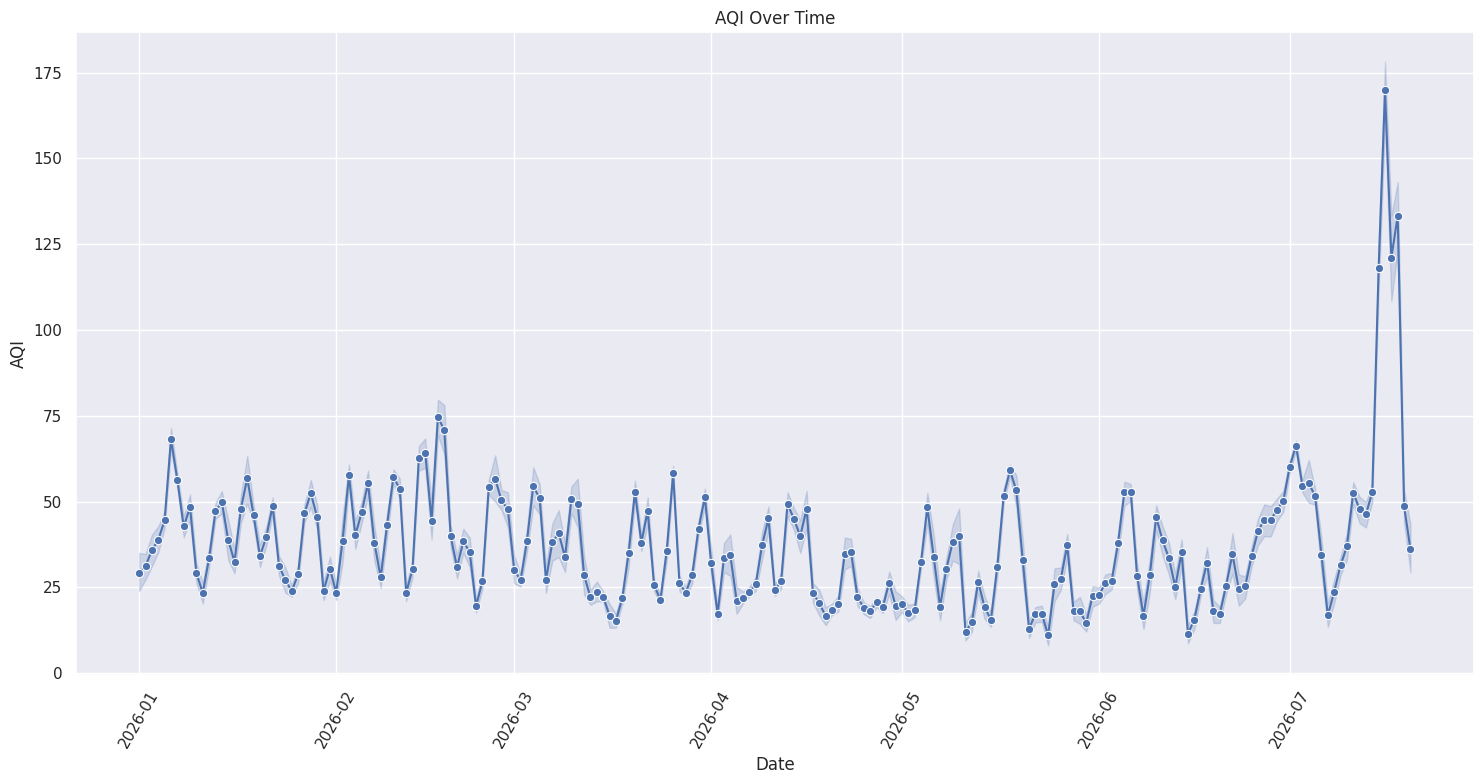

In [20]:
import matplotlib.pyplot as plt
import seaborn as sbn
sbn.set(style="darkgrid")

#plot AQI vs time
plt.figure(figsize=(15,8))
sbn.lineplot(x='Date', y='Daily AQI Value', data=df, marker='o')
plt.title('AQI Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

**4. Graphing AQi vs PM2.5 Concentration**

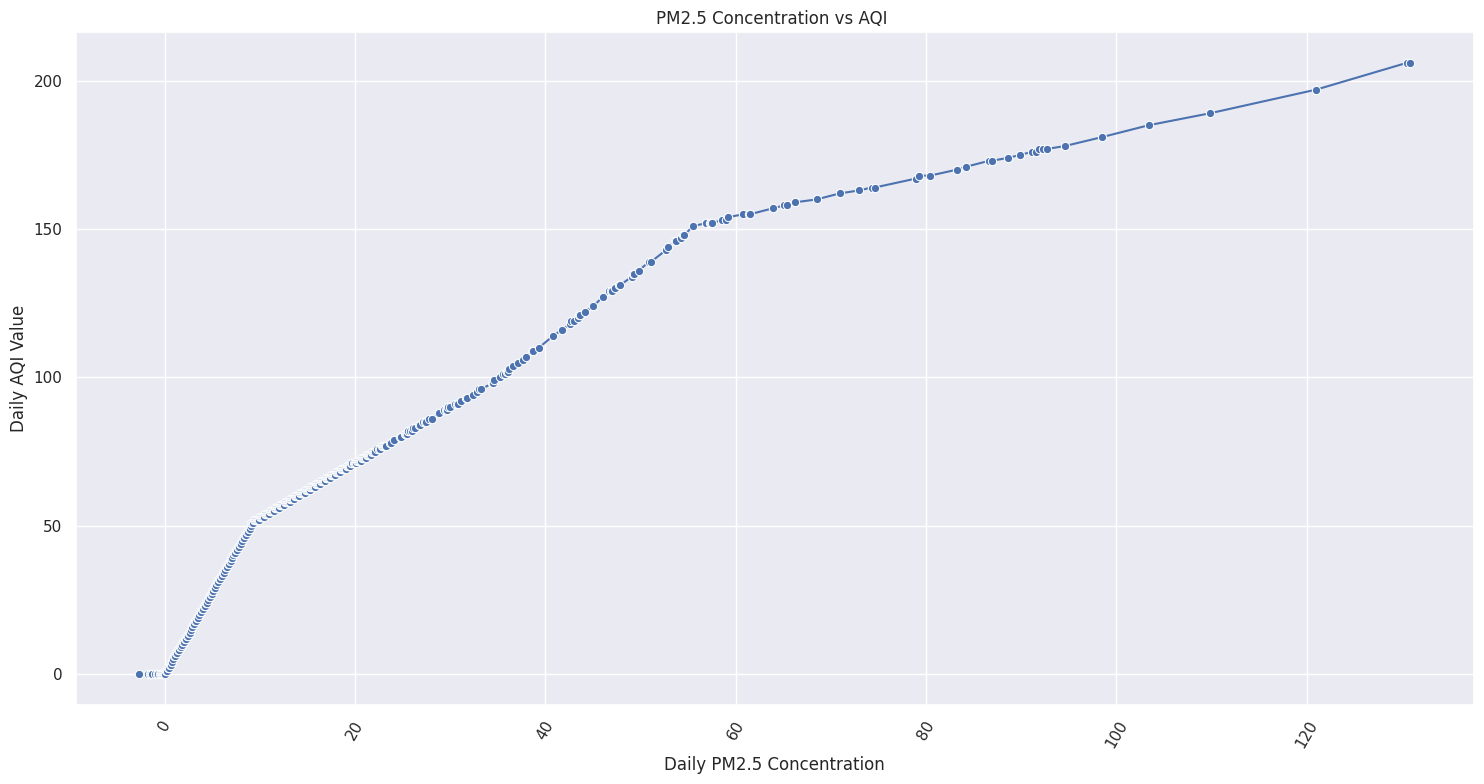

In [21]:
#plot AQI vs PM2.5
plt.figure(figsize=(15,8))
sbn.lineplot(x='Daily Mean PM2.5 Concentration', y='Daily AQI Value', data=df, marker='o')
plt.title('AQI vs PM2.5 Concentration')
plt.xlabel('Daily PM2.5 Concentration')
plt.ylabel('Daily AQI Value')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

**5. Linear Regression plot to evaluate AQI vs PM2.5 correlation**

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

#Prepare data to learn regression
x=df[['Daily Mean PM2.5 Concentration']].values
y=df['Daily AQI Value'].values

#Create and Fit the Model
model=LinearRegression()
model.fit(x,y)

#Predict AQI values
y_pred=model.predict(x)

#Calculate R2
r2=r2_score(y,y_pred)
print(f'R^2 value:{r2:.3f}')


R^2 value:0.843


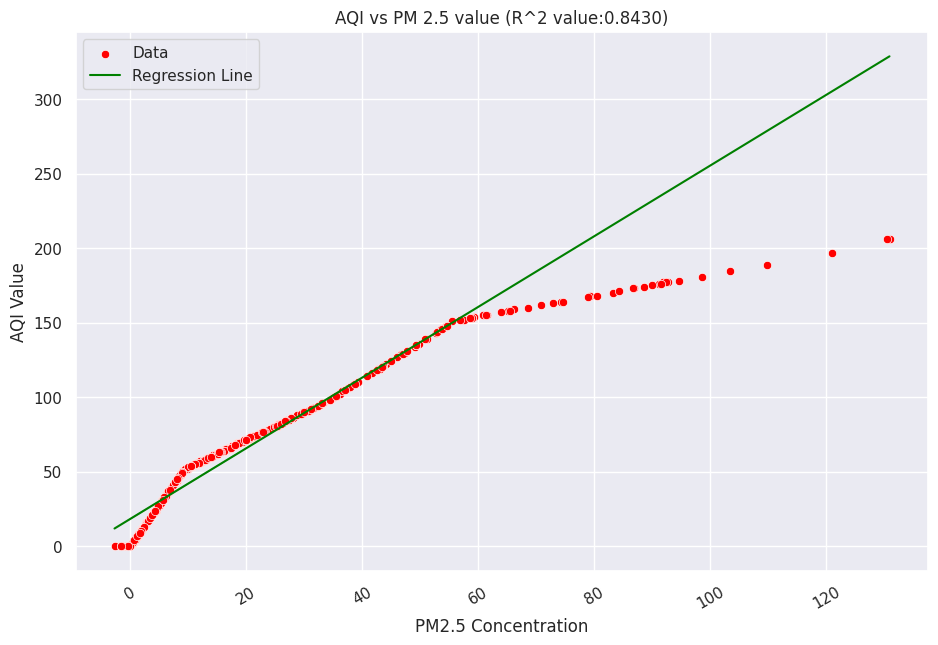

In [26]:
plt.figure(figsize=[11,7])

#Scatter Plot
sbn.scatterplot(x='Daily Mean PM2.5 Concentration', y='Daily AQI Value', data=df, color='red', label='Data')

#Regression Line
sbn.lineplot(x=df['Daily Mean PM2.5 Concentration'], y=y_pred, color='green', label='Regression Line')
plt.title(f'AQI vs PM 2.5 value (R^2 value:{r2:.4f})')
plt.xlabel('PM2.5 Concentration')
plt.ylabel('AQI Value')
plt.xticks(rotation=30)
plt.legend()
plt.show()

**6. Comparing AQI data between different years (2020 vs 2026)**

In [28]:
#2020
df_2020= pd.read_csv('aq_viz_plotval_newyork_2020_data.csv')
print('2020 Data Head:')
display(df_2020.head())

2020 Data Head:


,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,Method Code,Method Description,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2020,AQS,360010005,1,1.9,ug/m3 LC,11,ALBANY COUNTY HEALTH DEPT,1,100.0,...,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,10580.0,"Albany-Schenectady-Troy, NY",36,New York,1,Albany,42.64225,-73.75464
1,01/04/2020,AQS,360010005,1,9.6,ug/m3 LC,52,ALBANY COUNTY HEALTH DEPT,1,100.0,...,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,10580.0,"Albany-Schenectady-Troy, NY",36,New York,1,Albany,42.64225,-73.75464
2,01/07/2020,AQS,360010005,1,5.0,ug/m3 LC,28,ALBANY COUNTY HEALTH DEPT,1,100.0,...,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,10580.0,"Albany-Schenectady-Troy, NY",36,New York,1,Albany,42.64225,-73.75464
3,01/10/2020,AQS,360010005,1,5.2,ug/m3 LC,29,ALBANY COUNTY HEALTH DEPT,1,100.0,...,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,10580.0,"Albany-Schenectady-Troy, NY",36,New York,1,Albany,42.64225,-73.75464
4,01/13/2020,AQS,360010005,1,4.0,ug/m3 LC,22,ALBANY COUNTY HEALTH DEPT,1,100.0,...,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,10580.0,"Albany-Schenectady-Troy, NY",36,New York,1,Albany,42.64225,-73.75464


In [29]:
# Drop rows with any missing values from the 2020 DataFrame
df_2020 = df_2020.dropna()
# Convert 'Date' column to datetime objects for the 2020 DataFrame
df_2020['Date'] = pd.to_datetime(df_2020['Date'])

print('\n2020 Data Info after preprocessing:')
display(df_2020.info())


2020 Data Info after preprocessing:
<class 'pandas.core.frame.DataFrame'>
Index: 12508 entries, 0 to 12915
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Date                            12508 non-null  datetime64[ns]
 1   Source                          12508 non-null  object        
 2   Site ID                         12508 non-null  int64         
 3   POC                             12508 non-null  int64         
 4   Daily Mean PM2.5 Concentration  12508 non-null  float64       
 5   Units                           12508 non-null  object        
 6   Daily AQI Value                 12508 non-null  int64         
 7   Local Site Name                 12508 non-null  object        
 8   Daily Obs Count                 12508 non-null  int64         
 9   Percent Complete                12508 non-null  float64       
 10  AQS Parameter Code              12508 

None

In [31]:
#2026
df_2026= pd.read_csv('aq_viz_plotval_newyork_2026_data.csv')

df_2020['Date'] = pd.to_datetime(df_2020['Date'])
df_2026['Date'] = pd.to_datetime(df_2026['Date'])

#Extract Day and Month
df_2020['Month_Day'] = df_2020['Date'].dt.strftime('%m-%d')
df_2026['Month_Day'] = df_2026['Date'].dt.strftime('%m-%d')


In [ ]:
plt.figure(figsize=[13,9])

#Plot Year of 2020
sbn.scatterplot(x='Month_Day', y='Daily AQI Value', data=df, color='blue', label='2020', alpha=0.6)
#Plot Year of 2026
sbn.scatterplot(x='Month_Day', y='Daily AQI Value', data=df_2026, color='red', label='2026', alpha=0.5)
plt.xticks(rotation=45)
plt.title(f'Daily AQI vs Month-Day between 2020 vs 2026')
plt.xlabel('Month-Day')
plt.ylabel('Daily AQI')
plt.xticks(rotation=30)
plt.legend()
plt.show()

#Regression Line
sbn.lineplot(x=df['Daily Mean PM2.5 Concentration'], y=y_pred, color='green', label='Regression Line')
plt.title(f'AQI vs PM 2.5 value (R^2 value:{r2:.4f})')
plt.xlabel('PM2.5 Concentration')
plt.ylabel('AQI Value')
plt.xticks(rotation=30)
plt.legend()
plt.show()

In [ ]:
df['Year'] = df['Date'].dt.year
df_2020['Year'] = df_2020['Date'].dt.year

# Concatenate the two dataframes
df_combined = pd.concat([df, df_2020])

print('Combined DataFrame Head:')
display(df_combined.head())